In [52]:
# import os
# import numpy as np

In [53]:
# def split_batch_by_clip(npz_path, out_dir, prefix):
#     os.makedirs(out_dir, exist_ok=True)

#     data = np.load(npz_path, allow_pickle=True)

#     ppg = data["ppg"]
#     faces = data["faces"]
#     labels = data["labels"].reshape(-1)
#     clip_id = data["clip_id"].reshape(-1)

#     unique_clips = np.unique(clip_id)
#     print(f"{prefix}: total clips = {len(unique_clips)}")

#     for clip in unique_clips:
#         idx = np.where(clip_id == clip)[0]

#         save_path = os.path.join(out_dir, f"{prefix}_clip_{int(clip)}.npz")
#         np.savez_compressed(
#             save_path,
#             ppg=ppg[idx],
#             faces=faces[idx],
#             labels=labels[idx],
#             clip_id=clip_id[idx]
#         )
#         print(f"saved: {save_path} | windows = {len(idx)}")

#     print(f"Done: {prefix}")

In [54]:
# split_batch_by_clip("BATCH1.npz", "split_batches", "BATCH1")
# split_batch_by_clip("BATCH2.npz", "split_batches", "BATCH2")

In [55]:
split_dir = "split_batches"
files = sorted(os.listdir(split_dir))
print("num files:", len(files))
for f in files[:10]:
    print(f)

num files: 32
BATCH1_clip_1.npz
BATCH1_clip_10.npz
BATCH1_clip_11.npz
BATCH1_clip_12.npz
BATCH1_clip_13.npz
BATCH1_clip_14.npz
BATCH1_clip_15.npz
BATCH1_clip_16.npz
BATCH1_clip_2.npz
BATCH1_clip_3.npz


In [56]:
import os
import gc
import copy
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [57]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

In [58]:
all_class_labels = [0, 1, 2, 3]

split_dir = "split_batches"

def get_subject_clip_files(split_dir, subject_prefix):
    files = []
    for fname in os.listdir(split_dir):
        if fname.startswith(subject_prefix) and fname.endswith(".npz"):
            files.append(os.path.join(split_dir, fname))
    files = sorted(files)
    return files

subject_files = {
    "Batch1": get_subject_clip_files(split_dir, "BATCH1"),
    "Batch2": get_subject_clip_files(split_dir, "BATCH2"),
}

for subject, files in subject_files.items():
    print(subject, len(files))
    for f in files[:3]:
        print(" ", f)

Batch1 16
  split_batches\BATCH1_clip_1.npz
  split_batches\BATCH1_clip_10.npz
  split_batches\BATCH1_clip_11.npz
Batch2 16
  split_batches\BATCH2_clip_1.npz
  split_batches\BATCH2_clip_10.npz
  split_batches\BATCH2_clip_11.npz


In [59]:
def load_small_npz(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    return {
        "ppg": np.asarray(data["ppg"], dtype=np.float32),
        "faces": np.asarray(data["faces"], dtype=np.float32),
        "labels": np.asarray(data["labels"], dtype=np.int64).reshape(-1),
        "clip_id": np.asarray(data["clip_id"], dtype=np.int64).reshape(-1),
    }

def load_multiple_small_npz(npz_paths):
    ppg_list = []
    faces_list = []
    labels_list = []
    clip_list = []

    for path in npz_paths:
        d = load_small_npz(path)
        ppg_list.append(d["ppg"])
        faces_list.append(d["faces"])
        labels_list.append(d["labels"])
        clip_list.append(d["clip_id"])

    return {
        "ppg": np.concatenate(ppg_list, axis=0),
        "faces": np.concatenate(faces_list, axis=0),
        "labels": np.concatenate(labels_list, axis=0),
        "clip_id": np.concatenate(clip_list, axis=0),
    }

In [60]:
example_file = subject_files["Batch1"][0]
example_data = load_small_npz(example_file)

print("example file:", example_file)
for k, v in example_data.items():
    print(k, v.shape, v.dtype)

example file: split_batches\BATCH1_clip_1.npz
ppg (120, 1, 250) float32
faces (120, 16, 3, 64, 64) float32
labels (120,) int64
clip_id (120,) int64


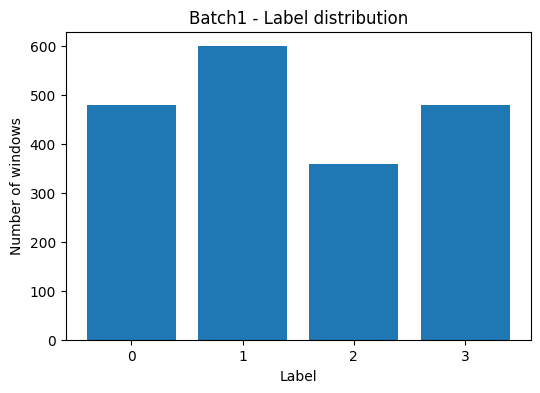

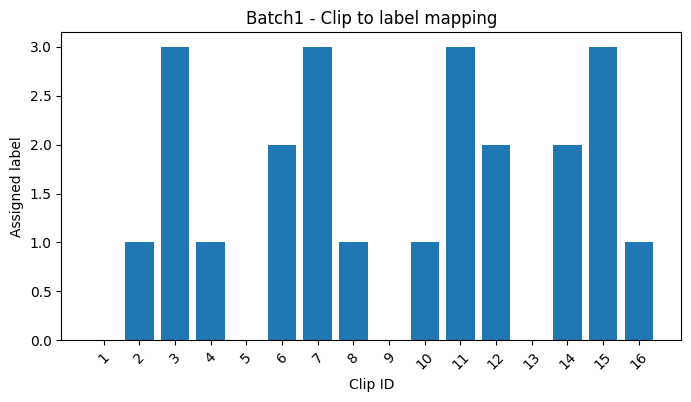

,clip_id,label
0,1,0
1,2,1
2,3,3
3,4,1
4,5,0
5,6,2
6,7,3
7,8,1
8,9,0
9,10,1


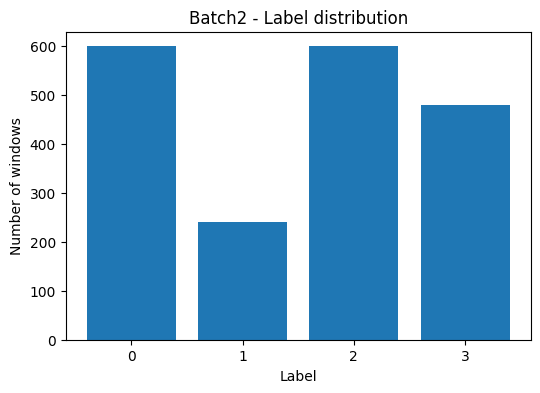

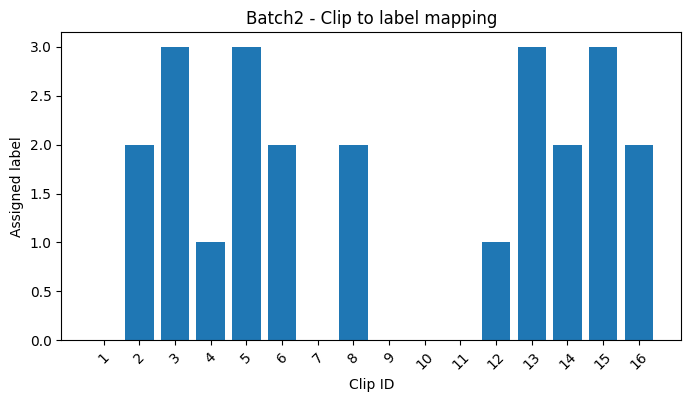

,clip_id,label
0,1,0
1,2,2
2,3,3
3,4,1
4,5,3
5,6,2
6,7,0
7,8,2
8,9,0
9,10,0


In [61]:
for subject_name, files in subject_files.items():
    data_subject = load_multiple_small_npz(files)

    labels = data_subject["labels"]
    clip_ids = data_subject["clip_id"]

    unique_labels, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(6, 4))
    plt.bar([str(x) for x in unique_labels], counts)
    plt.xlabel("Label")
    plt.ylabel("Number of windows")
    plt.title(f"{subject_name} - Label distribution")
    plt.show()

    clip_label_df = (
        pd.DataFrame({"clip_id": clip_ids, "label": labels})
        .groupby("clip_id")["label"]
        .first()
        .reset_index()
        .sort_values("clip_id")
    )

    plt.figure(figsize=(8, 4))
    plt.bar(clip_label_df["clip_id"].astype(str), clip_label_df["label"])
    plt.xlabel("Clip ID")
    plt.ylabel("Assigned label")
    plt.title(f"{subject_name} - Clip to label mapping")
    plt.xticks(rotation=45)
    plt.show()

    display(clip_label_df)

    del data_subject
    gc.collect()

In [62]:
class MultiModalDataset(Dataset):
    def __init__(self, faces, ppg, labels=None):
        self.faces = faces
        self.ppg = ppg
        self.labels = labels

    def __len__(self):
        return len(self.faces)

    def __getitem__(self, idx):
        face_item = torch.from_numpy(self.faces[idx]).float()
        ppg_item = torch.from_numpy(self.ppg[idx]).float()

        if self.labels is None:
            return face_item, ppg_item
        else:
            label_item = torch.tensor(self.labels[idx], dtype=torch.long)
            return face_item, ppg_item, label_item

## Define the model-level fusion feature extractor 
- face branch: Frame-by-frame 2D CNN, then average the results of 16 frames
- PPG branch: 1D CNN
- fusion: Feature concatenation

In [63]:
class FaceEncoder(nn.Module):
    def __init__(self, out_dim=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(32, out_dim)

    def forward(self, x):
        # x: [B, T, 3, 64, 64]
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.cnn(x)
        x = x.view(B * T, -1)
        x = self.fc(x)
        x = x.view(B, T, -1).mean(dim=1)
        return x


class PPGEncoder(nn.Module):
    def __init__(self, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(32, out_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x


class FusionExtractor(nn.Module):
    def __init__(self, face_dim=64, ppg_dim=64, fusion_dim=64, num_classes=4):
        super().__init__()
        self.face_encoder = FaceEncoder(face_dim)
        self.ppg_encoder = PPGEncoder(ppg_dim)

        self.fusion = nn.Sequential(
            nn.Linear(face_dim + ppg_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.classifier = nn.Linear(fusion_dim, num_classes)

    def extract_features(self, faces, ppg):
        face_feat = self.face_encoder(faces)
        ppg_feat = self.ppg_encoder(ppg)
        fused = torch.cat([face_feat, ppg_feat], dim=1)
        fused = self.fusion(fused)
        return fused

    def forward(self, faces, ppg):
        fused = self.extract_features(faces, ppg)
        return self.classifier(fused)

In [64]:
def make_clipwise_val_split(train_clip_ids, val_ratio=0.2, seed=42):
    unique_clips = np.unique(train_clip_ids)
    rng = np.random.RandomState(seed)
    clips = unique_clips.copy()
    rng.shuffle(clips)

    n_val = max(1, int(round(len(clips) * val_ratio)))
    val_clips = clips[:n_val]
    train_clips = clips[n_val:]
    return set(train_clips.tolist()), set(val_clips.tolist())


def get_indices_by_clip(clip_ids, selected_clips):
    return np.where(np.isin(clip_ids, list(selected_clips)))[0]


def train_feature_extractor(
    faces_train, ppg_train, y_train, clip_train,
    num_classes=4,
    batch_size=4,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=6,
    patience=2,
    seed=42
):
    seed_everything(seed)

    train_clips, val_clips = make_clipwise_val_split(clip_train, val_ratio=0.2, seed=seed)
    tr_idx = get_indices_by_clip(clip_train, train_clips)
    va_idx = get_indices_by_clip(clip_train, val_clips)

    ds_tr = MultiModalDataset(faces_train[tr_idx], ppg_train[tr_idx], y_train[tr_idx])
    ds_va = MultiModalDataset(faces_train[va_idx], ppg_train[va_idx], y_train[va_idx])

    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0)

    model = FusionExtractor(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_loss = np.inf
    wait = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for faces, ppg, labels in dl_tr:
            faces = faces.to(device)
            ppg = ppg.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(faces, ppg)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for faces, ppg, labels in dl_va:
                faces = faces.to(device)
                ppg = ppg.to(device)
                labels = labels.to(device)

                logits = model(faces, ppg)
                loss = criterion(logits, labels)
                val_losses.append(loss.item())

        mean_train_loss = float(np.mean(train_losses))
        mean_val_loss = float(np.mean(val_losses))
        print(f"Epoch {epoch:02d} | train_loss={mean_train_loss:.4f} | val_loss={mean_val_loss:.4f}")

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


@torch.no_grad()
def extract_features(model, faces, ppg, batch_size=8):
    ds = MultiModalDataset(faces, ppg, labels=None)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    feats = []

    for faces_b, ppg_b in dl:
        faces_b = faces_b.to(device)
        ppg_b = ppg_b.to(device)
        fused = model.extract_features(faces_b, ppg_b)
        feats.append(fused.cpu().numpy())

    return np.concatenate(feats, axis=0)


def get_classifier(name, random_state=42):
    if name == "logreg":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                random_state=random_state
            ))
        ])
    elif name == "svm":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="linear",
                probability=True,
                random_state=random_state
            ))
        ])
    elif name == "rf":
        return RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        )
    else:
        raise ValueError(f"Unknown classifier: {name}")


def evaluate_predictions(y_true, y_pred, labels_for_eval=all_class_labels):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true, y_pred,
        average="macro",
        labels=labels_for_eval,
        zero_division=0
    )

    precision, recall, f1_each, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=labels_for_eval,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_for_eval)

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "confusion_matrix": cm,
        "per_class_precision": {c: p for c, p in zip(labels_for_eval, precision)},
        "per_class_recall": {c: r for c, r in zip(labels_for_eval, recall)},
        "per_class_f1": {c: f for c, f in zip(labels_for_eval, f1_each)},
        "support": {c: s for c, s in zip(labels_for_eval, support)},
    }


def aggregate_video_predictions(y_true, y_prob, clip_ids):
    unique_clips = np.unique(clip_ids)

    y_true_video = []
    y_pred_video = []

    for clip in unique_clips:
        idx = np.where(clip_ids == clip)[0]
        mean_prob = y_prob[idx].mean(axis=0)
        pred_label = int(np.argmax(mean_prob))
        true_label = int(y_true[idx][0])

        y_true_video.append(true_label)
        y_pred_video.append(pred_label)

    return np.array(y_true_video), np.array(y_pred_video)

## Define the model-level fusion feature extractor 
- face branch: Frame-by-frame 2D CNN, then average the results of 16 frames
- PPG branch: 1D CNN
- fusion: Feature concatenation

In [65]:
def run_lovo_for_one_subject_from_files(subject_name, clip_files, seed=42):
    print(f"\n===== Running LOVO for {subject_name} | total clips = {len(clip_files)} =====")

    fold_records = []

    prediction_store = {
        "logreg": {"window_true": [], "window_pred": [], "video_true": [], "video_pred": []},
        "svm": {"window_true": [], "window_pred": [], "video_true": [], "video_pred": []},
        "rf": {"window_true": [], "window_pred": [], "video_true": [], "video_pred": []},
    }

    for fold_idx in range(len(clip_files)):
        test_file = clip_files[fold_idx]
        train_files = [f for i, f in enumerate(clip_files) if i != fold_idx]

        print(f"\n===== Fold {fold_idx + 1}/{len(clip_files)} | test file = {os.path.basename(test_file)} =====")

        train_data = load_multiple_small_npz(train_files)
        test_data = load_small_npz(test_file)

        faces_train = train_data["faces"]
        ppg_train = train_data["ppg"]
        y_train = train_data["labels"]
        clip_train = train_data["clip_id"]

        faces_test = test_data["faces"]
        ppg_test = test_data["ppg"]
        y_test = test_data["labels"]
        clip_test = test_data["clip_id"]

        model = train_feature_extractor(
            faces_train, ppg_train, y_train, clip_train,
            num_classes=4,
            batch_size=4,
            lr=1e-3,
            weight_decay=1e-4,
            max_epochs=6,
            patience=2,
            seed=seed
        )

        X_train = extract_features(model, faces_train, ppg_train, batch_size=8)
        X_test = extract_features(model, faces_test, ppg_test, batch_size=8)

        for clf_name in ["logreg", "svm", "rf"]:
            clf = get_classifier(clf_name, random_state=seed)
            clf.fit(X_train, y_train)

            y_pred_window = clf.predict(X_test)
            y_prob_window = clf.predict_proba(X_test)

            metrics_window = evaluate_predictions(y_test, y_pred_window)
            y_true_video, y_pred_video = aggregate_video_predictions(y_test, y_prob_window, clip_test)
            metrics_video = evaluate_predictions(y_true_video, y_pred_video)

            print(
                f"[{clf_name.upper():>6s}] "
                f"Window acc={metrics_window['accuracy']:.4f}, "
                f"bal_acc={metrics_window['balanced_accuracy']:.4f}, "
                f"macro_f1={metrics_window['macro_f1']:.4f} | "
                f"Video acc={metrics_video['accuracy']:.4f}, "
                f"bal_acc={metrics_video['balanced_accuracy']:.4f}, "
                f"macro_f1={metrics_video['macro_f1']:.4f}"
            )

            fold_records.append({
                "subject": subject_name,
                "fold": fold_idx + 1,
                "test_file": os.path.basename(test_file),
                "classifier": clf_name,

                "window_accuracy": metrics_window["accuracy"],
                "window_balanced_accuracy": metrics_window["balanced_accuracy"],
                "window_macro_f1": metrics_window["macro_f1"],

                "video_accuracy": metrics_video["accuracy"],
                "video_balanced_accuracy": metrics_video["balanced_accuracy"],
                "video_macro_f1": metrics_video["macro_f1"],
            })

            prediction_store[clf_name]["window_true"].extend(y_test.tolist())
            prediction_store[clf_name]["window_pred"].extend(y_pred_window.tolist())
            prediction_store[clf_name]["video_true"].extend(y_true_video.tolist())
            prediction_store[clf_name]["video_pred"].extend(y_pred_video.tolist())

        del train_data, test_data
        del faces_train, ppg_train, y_train, clip_train
        del faces_test, ppg_test, y_test, clip_test
        del model, X_train, X_test
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(fold_records), prediction_store

In [66]:
all_fold_tables = []
all_prediction_store = {}

for subject_name, files in subject_files.items():
    df_subject, pred_subject = run_lovo_for_one_subject_from_files(subject_name, files, seed=42)
    all_fold_tables.append(df_subject)
    all_prediction_store[subject_name] = pred_subject

results_df = pd.concat(all_fold_tables, axis=0, ignore_index=True)

print("Finished.")
display(results_df.head())


===== Running LOVO for Batch1 | total clips = 16 =====

===== Fold 1/16 | test file = BATCH1_clip_1.npz =====
Epoch 01 | train_loss=1.3694 | val_loss=1.4400
Epoch 02 | train_loss=1.2873 | val_loss=2.6229
Epoch 03 | train_loss=1.1790 | val_loss=2.5013
Early stopping triggered.
[LOGREG] Window acc=0.3667, bal_acc=0.3667, macro_f1=0.1341 | Video acc=0.0000, bal_acc=0.0000, macro_f1=0.0000
[   SVM] Window acc=0.4167, bal_acc=0.4167, macro_f1=0.1471 | Video acc=0.0000, bal_acc=0.0000, macro_f1=0.0000
[    RF] Window acc=0.3833, bal_acc=0.3833, macro_f1=0.1386 | Video acc=1.0000, bal_acc=1.0000, macro_f1=0.2500

===== Fold 2/16 | test file = BATCH1_clip_10.npz =====
Epoch 01 | train_loss=1.3726 | val_loss=1.4963
Epoch 02 | train_loss=1.2517 | val_loss=2.6418
Epoch 03 | train_loss=1.1648 | val_loss=3.0334
Early stopping triggered.
[LOGREG] Window acc=0.2583, bal_acc=0.2583, macro_f1=0.1026 | Video acc=0.0000, bal_acc=0.0000, macro_f1=0.0000
[   SVM] Window acc=0.2667, bal_acc=0.2667, macro_f

,subject,fold,test_file,classifier,window_accuracy,window_balanced_accuracy,window_macro_f1,video_accuracy,video_balanced_accuracy,video_macro_f1
0,Batch1,1,BATCH1_clip_1.npz,logreg,0.366667,0.366667,0.134146,0.0,0.0,0.00
1,Batch1,1,BATCH1_clip_1.npz,svm,0.416667,0.416667,0.147059,0.0,0.0,0.00
2,Batch1,1,BATCH1_clip_1.npz,rf,0.383333,0.383333,0.138554,1.0,1.0,0.25
3,Batch1,2,BATCH1_clip_10.npz,logreg,0.258333,0.258333,0.102649,0.0,0.0,0.00
4,Batch1,2,BATCH1_clip_10.npz,svm,0.266667,0.266667,0.105263,0.0,0.0,0.00


fold-level results

In [67]:
results_df

,subject,fold,test_file,classifier,window_accuracy,window_balanced_accuracy,window_macro_f1,video_accuracy,video_balanced_accuracy,video_macro_f1
0,Batch1,1,BATCH1_clip_1.npz,logreg,0.366667,0.366667,0.134146,0.0,0.0,0.00
1,Batch1,1,BATCH1_clip_1.npz,svm,0.416667,0.416667,0.147059,0.0,0.0,0.00
2,Batch1,1,BATCH1_clip_1.npz,rf,0.383333,0.383333,0.138554,1.0,1.0,0.25
3,Batch1,2,BATCH1_clip_10.npz,logreg,0.258333,0.258333,0.102649,0.0,0.0,0.00
4,Batch1,2,BATCH1_clip_10.npz,svm,0.266667,0.266667,0.105263,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...
91,Batch2,15,BATCH2_clip_8.npz,svm,0.050000,0.050000,0.023810,0.0,0.0,0.00
92,Batch2,15,BATCH2_clip_8.npz,rf,0.050000,0.050000,0.023810,0.0,0.0,0.00
93,Batch2,16,BATCH2_clip_9.npz,logreg,0.100000,0.100000,0.045455,0.0,0.0,0.00
94,Batch2,16,BATCH2_clip_9.npz,svm,0.033333,0.033333,0.016129,0.0,0.0,0.00


## Subject-level Average Results 
First, calculate the average of the LOVO folds within each subject.

In [68]:
subject_summary = (
    results_df
    .groupby(["subject", "classifier"])[
        [
            "window_accuracy",
            "window_balanced_accuracy",
            "window_macro_f1",
            "video_accuracy",
            "video_balanced_accuracy",
            "video_macro_f1"
        ]
    ]
    .mean()
    .reset_index()
)

subject_summary

,subject,classifier,window_accuracy,window_balanced_accuracy,window_macro_f1,video_accuracy,video_balanced_accuracy,video_macro_f1
0,Batch1,logreg,0.114062,0.114062,0.047038,0.0000,0.0000,0.000000
1,Batch1,rf,0.213542,0.213542,0.076627,0.2500,0.2500,0.062500
2,Batch1,svm,0.134896,0.134896,0.053113,0.0000,0.0000,0.000000
3,Batch2,logreg,0.139063,0.139063,0.054831,0.1250,0.1250,0.031250
4,Batch2,rf,0.177083,0.177083,0.071094,0.0000,0.0000,0.000000
5,Batch2,svm,0.082292,0.082292,0.034587,0.0625,0.0625,0.015625


## Final Average Result 
According to the within-subject setting, first calculate the average for each subject, and then take the average of the two subjects.

In [69]:
final_summary = (
    subject_summary
    .groupby("classifier")[
        [
            "window_accuracy",
            "window_balanced_accuracy",
            "window_macro_f1",
            "video_accuracy",
            "video_balanced_accuracy",
            "video_macro_f1"
        ]
    ]
    .mean()
    .reset_index()
)

final_summary

,classifier,window_accuracy,window_balanced_accuracy,window_macro_f1,video_accuracy,video_balanced_accuracy,video_macro_f1
0,logreg,0.126562,0.126562,0.050934,0.06250,0.06250,0.015625
1,rf,0.195312,0.195312,0.073860,0.12500,0.12500,0.031250
2,svm,0.108594,0.108594,0.043850,0.03125,0.03125,0.007812


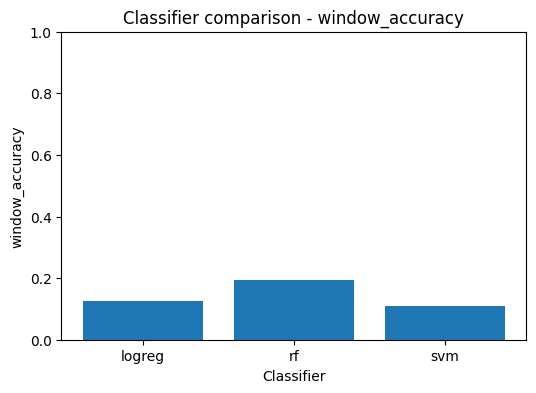

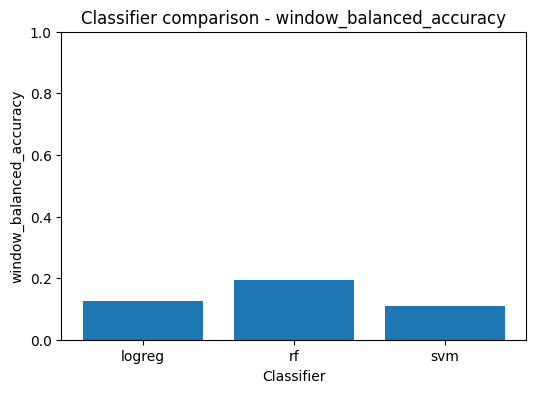

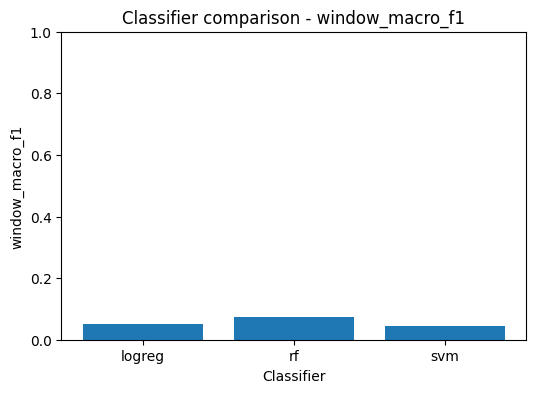

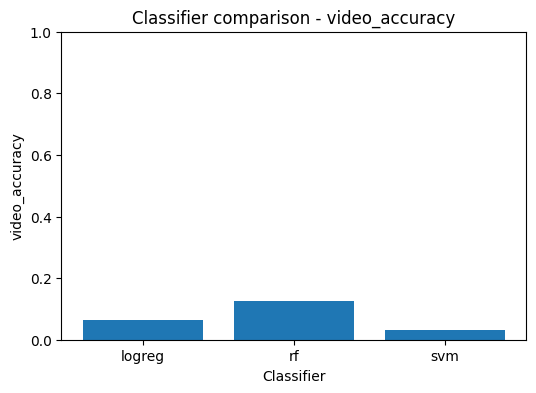

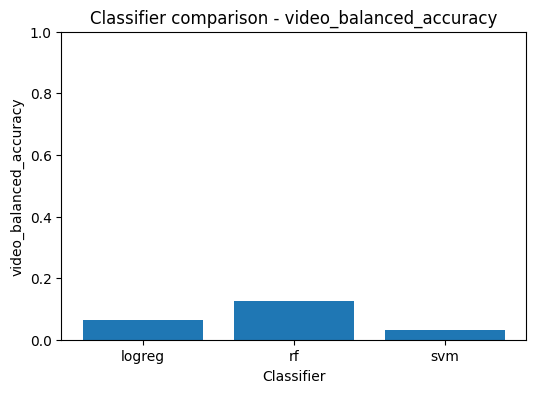

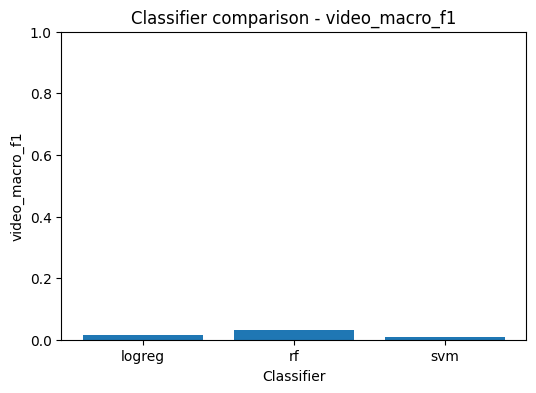

In [70]:
metrics_to_plot = [
    "window_accuracy",
    "window_balanced_accuracy",
    "window_macro_f1",
    "video_accuracy",
    "video_balanced_accuracy",
    "video_macro_f1"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(final_summary["classifier"], final_summary[metric])
    plt.ylim(0, 1)
    plt.xlabel("Classifier")
    plt.ylabel(metric)
    plt.title(f"Classifier comparison - {metric}")
    plt.show()

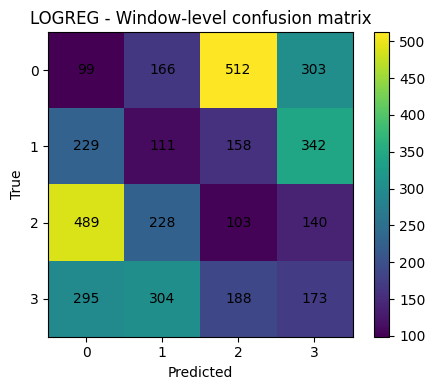

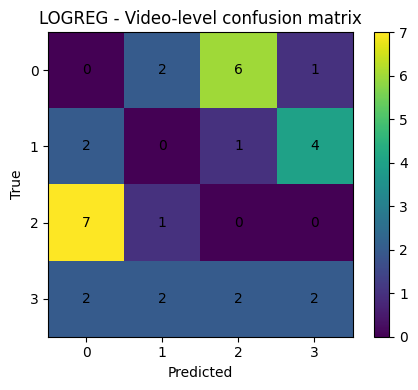

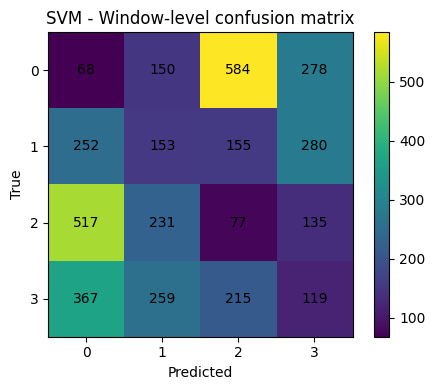

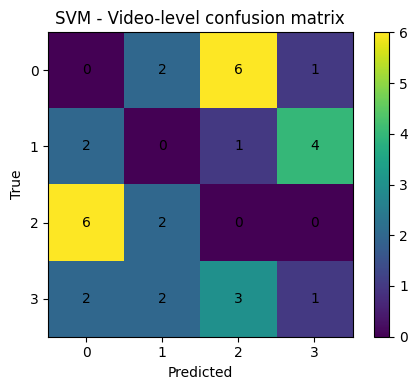

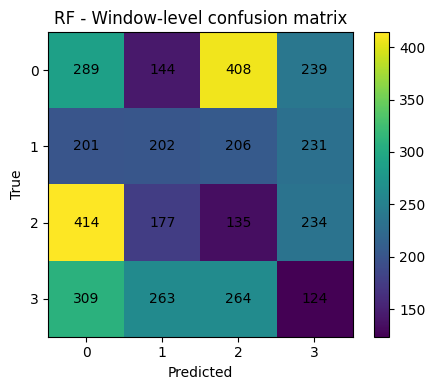

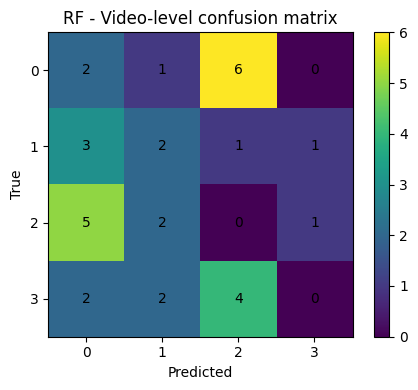

In [71]:
def plot_confusion_matrix(cm, title, labels=all_class_labels):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


for clf_name in ["logreg", "svm", "rf"]:
    window_true_all, window_pred_all = [], []
    video_true_all, video_pred_all = [], []

    for subject_name in all_prediction_store:
        window_true_all.extend(all_prediction_store[subject_name][clf_name]["window_true"])
        window_pred_all.extend(all_prediction_store[subject_name][clf_name]["window_pred"])
        video_true_all.extend(all_prediction_store[subject_name][clf_name]["video_true"])
        video_pred_all.extend(all_prediction_store[subject_name][clf_name]["video_pred"])

    cm_window = confusion_matrix(window_true_all, window_pred_all, labels=all_class_labels)
    cm_video = confusion_matrix(video_true_all, video_pred_all, labels=all_class_labels)

    plot_confusion_matrix(cm_window, f"{clf_name.upper()} - Window-level confusion matrix")
    plot_confusion_matrix(cm_video, f"{clf_name.upper()} - Video-level confusion matrix")

===== LOGREG | Window-level per-class metrics =====


,class,precision,recall,f1,support
0,0,0.089029,0.091667,0.090328,1080
1,1,0.137206,0.132143,0.134627,840
2,2,0.107180,0.107292,0.107236,960
3,3,0.180585,0.180208,0.180396,960


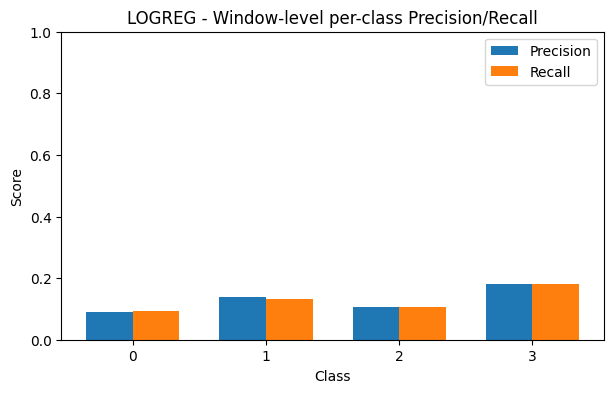

===== LOGREG | Video-level per-class metrics =====


,class,precision,recall,f1,support
0,0,0.000000,0.00,0.000000,9
1,1,0.000000,0.00,0.000000,7
2,2,0.000000,0.00,0.000000,8
3,3,0.285714,0.25,0.266667,8


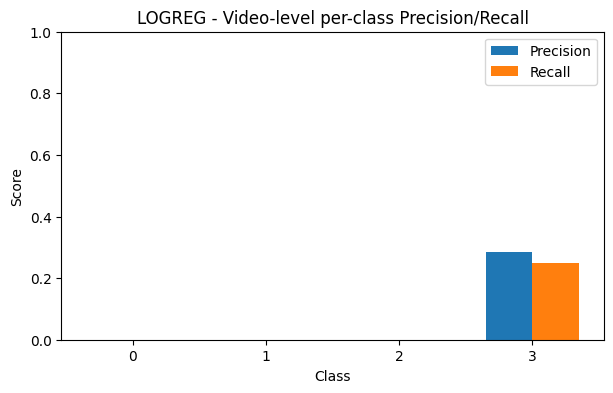

===== SVM | Window-level per-class metrics =====


,class,precision,recall,f1,support
0,0,0.056478,0.062963,0.059545,1080
1,1,0.192938,0.182143,0.187385,840
2,2,0.074685,0.080208,0.077348,960
3,3,0.146552,0.123958,0.134312,960


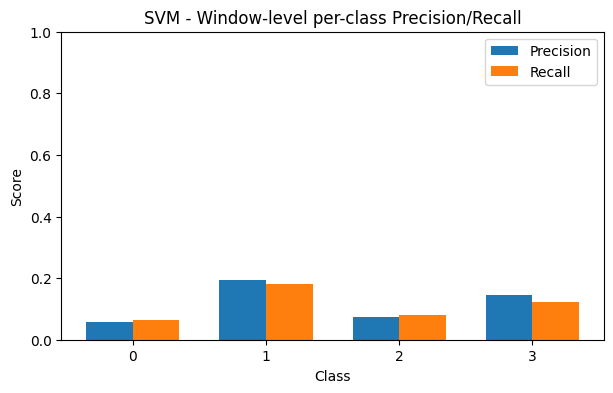

===== SVM | Video-level per-class metrics =====


,class,precision,recall,f1,support
0,0,0.000000,0.000,0.000000,9
1,1,0.000000,0.000,0.000000,7
2,2,0.000000,0.000,0.000000,8
3,3,0.166667,0.125,0.142857,8


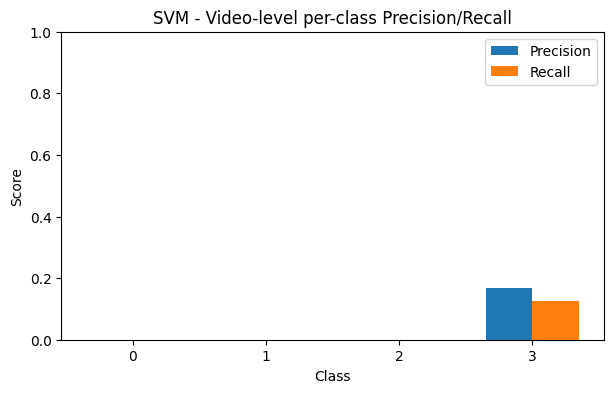

===== RF | Window-level per-class metrics =====


,class,precision,recall,f1,support
0,0,0.238252,0.267593,0.252072,1080
1,1,0.256997,0.240476,0.248462,840
2,2,0.133268,0.140625,0.136847,960
3,3,0.149758,0.129167,0.138702,960


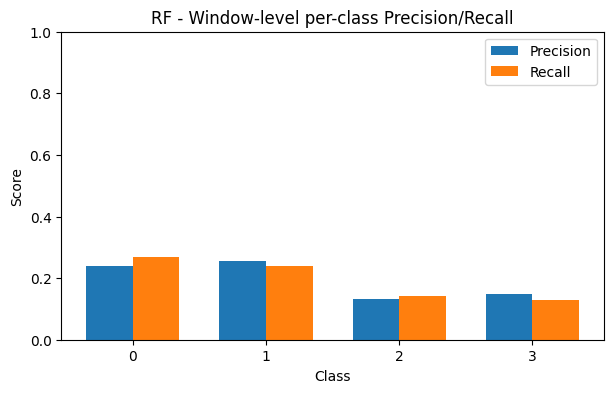

===== RF | Video-level per-class metrics =====


,class,precision,recall,f1,support
0,0,0.166667,0.222222,0.190476,9
1,1,0.285714,0.285714,0.285714,7
2,2,0.000000,0.000000,0.000000,8
3,3,0.000000,0.000000,0.000000,8


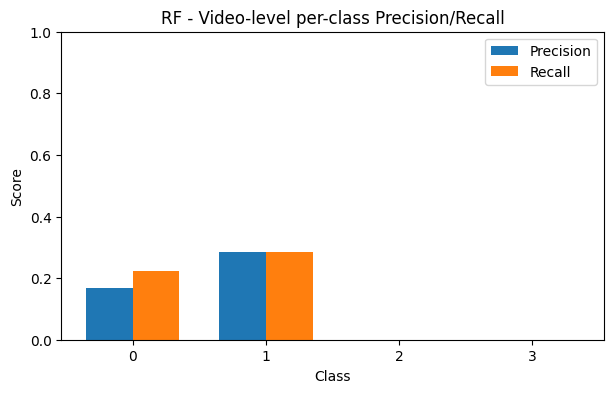

In [72]:
def compute_per_class_table(y_true, y_pred, labels=all_class_labels):
    precision, recall, f1_each, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=labels,
        zero_division=0
    )
    return pd.DataFrame({
        "class": labels,
        "precision": precision,
        "recall": recall,
        "f1": f1_each,
        "support": support
    })


for clf_name in ["logreg", "svm", "rf"]:
    window_true_all, window_pred_all = [], []
    video_true_all, video_pred_all = [], []

    for subject_name in all_prediction_store:
        window_true_all.extend(all_prediction_store[subject_name][clf_name]["window_true"])
        window_pred_all.extend(all_prediction_store[subject_name][clf_name]["window_pred"])
        video_true_all.extend(all_prediction_store[subject_name][clf_name]["video_true"])
        video_pred_all.extend(all_prediction_store[subject_name][clf_name]["video_pred"])

    df_window = compute_per_class_table(window_true_all, window_pred_all)
    df_video = compute_per_class_table(video_true_all, video_pred_all)

    print(f"===== {clf_name.upper()} | Window-level per-class metrics =====")
    display(df_window)

    plt.figure(figsize=(7, 4))
    x = np.arange(len(df_window))
    width = 0.35
    plt.bar(x - width/2, df_window["precision"], width=width, label="Precision")
    plt.bar(x + width/2, df_window["recall"], width=width, label="Recall")
    plt.xticks(x, df_window["class"])
    plt.ylim(0, 1)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title(f"{clf_name.upper()} - Window-level per-class Precision/Recall")
    plt.legend()
    plt.show()

    print(f"===== {clf_name.upper()} | Video-level per-class metrics =====")
    display(df_video)

    plt.figure(figsize=(7, 4))
    x = np.arange(len(df_video))
    width = 0.35
    plt.bar(x - width/2, df_video["precision"], width=width, label="Precision")
    plt.bar(x + width/2, df_video["recall"], width=width, label="Recall")
    plt.xticks(x, df_video["class"])
    plt.ylim(0, 1)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title(f"{clf_name.upper()} - Video-level per-class Precision/Recall")
    plt.legend()
    plt.show()

In [73]:
results_df.to_csv("model_level_lovo_all_folds.csv", index=False)
subject_summary.to_csv("model_level_lovo_subject_summary.csv", index=False)
final_summary.to_csv("model_level_lovo_final_summary.csv", index=False)

print("Saved:")
print("- model_level_lovo_all_folds.csv")
print("- model_level_lovo_subject_summary.csv")
print("- model_level_lovo_final_summary.csv")

Saved:
- model_level_lovo_all_folds.csv
- model_level_lovo_subject_summary.csv
- model_level_lovo_final_summary.csv
